# Economic Complexity Index per Polity per Century

We compute a Hidalgo-Hausmann Economic Complexity Index (ECI) treating
**occupations** as products and **polities** as locations.

- $N_{ik,t}$: HPI-weighted count of active individuals in polity $i$ with
  occupation $k$ during century $t$. HPI = number of distinct external
  catalogs the individual is referenced in (`identifiers` table).
- Activity bin: `floruit_year // 100` (so century `19` = years 1900-1999).
- Specialisation: $M_{ik}=1$ if RCA $\geq 1$, else $0$.
- Iterative ECI from the second-largest eigenvector of
  $D^{-1}\,M\,U^{-1}\,M^{T}$ (z-scored within each century).

Pipeline source: `scripts/_one_off/compute_eci_polity_century.py`.  
Output table: `data/eci_polity_century.parquet`.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import polars as pl
import pandas as pd  # plotting/matrix boundary only — heatmaps use pivot_table/.iloc
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DATA = Path('../data/eci_polity_century.parquet')
df_pl = pl.read_parquet(DATA).filter(pl.col('eci').is_not_null())
df = df_pl.to_pandas()  # keep as pandas: heatmap/pivot_table flow downstream
print(f'rows: {len(df):,}  |  centuries: {df.century.min()}..{df.century.max()}  |  polities: {df.polity_id.nunique():,}')
df.head()


## 1. Coverage: how many polities have an ECI in each century?


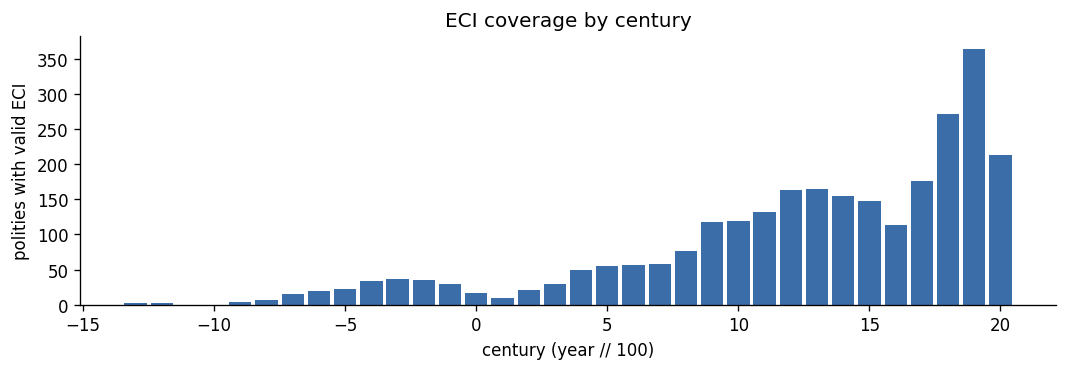

In [2]:
cov = df.groupby('century').size()
fig, ax = plt.subplots(figsize=(9, 3.2), dpi=120)
ax.bar(cov.index, cov.values, color='#3b6ea8', width=0.85)
ax.set_xlabel('century (year // 100)')
ax.set_ylabel('polities with valid ECI')
ax.set_title('ECI coverage by century')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## 2. Top-15 polities by ECI in selected centuries

Picking a few illustrative centuries: 5th BCE (Greek/Warring States era),
10th, 14th, 17th, 18th (= 1800-1899), 19th (= 1900-1999).


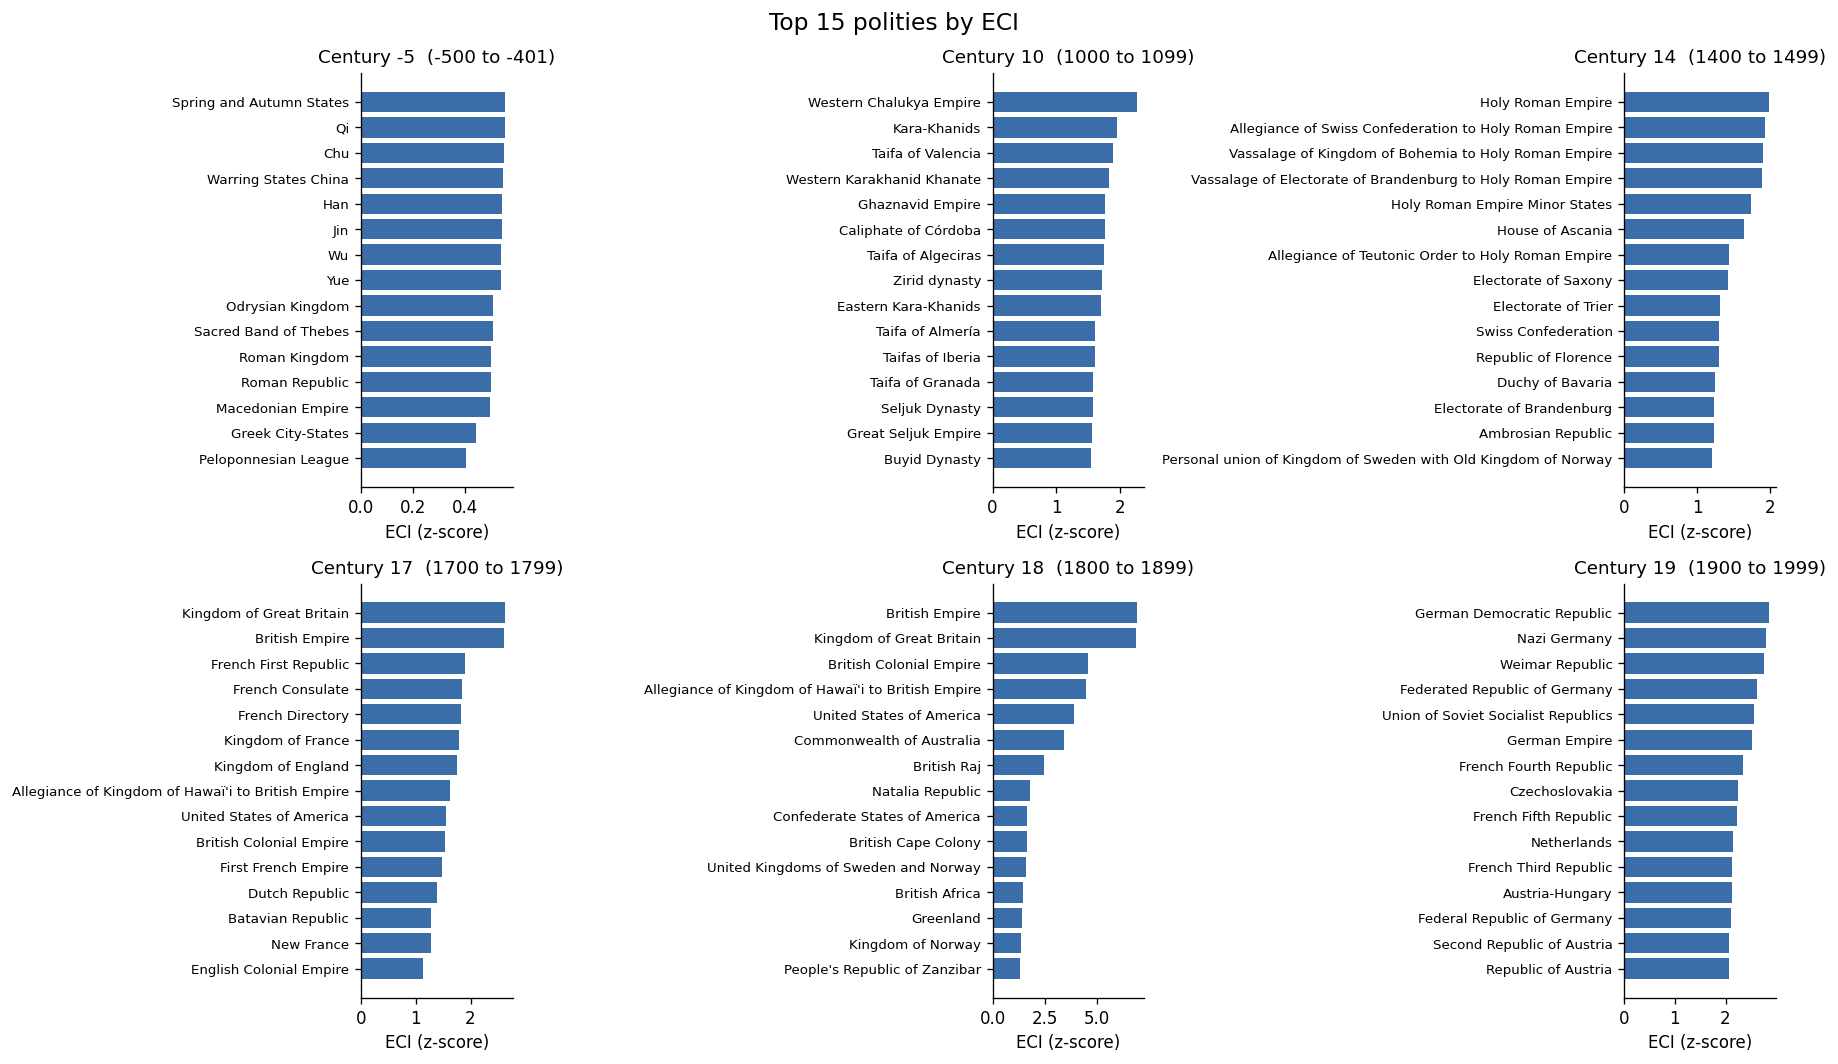

In [3]:
highlight_centuries = [-5, 10, 14, 17, 18, 19]
fig, axes = plt.subplots(2, 3, figsize=(15, 9), dpi=120)
for ax, c in zip(axes.flat, highlight_centuries):
    sub = df[df.century == c].nlargest(15, 'eci')
    label = f'{c*100} to {c*100+99}'
    ax.barh(sub.polity_name[::-1], sub.eci[::-1], color='#3b6ea8')
    ax.set_title(f'Century {c}  ({label})', fontsize=11)
    ax.set_xlabel('ECI (z-score)')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
fig.suptitle('Top 15 polities by ECI', fontsize=14)
plt.tight_layout(); plt.show()


## 3. ECI heatmap of long-lived polities

Polities that appear in at least 6 centuries — easier to read as a heatmap.


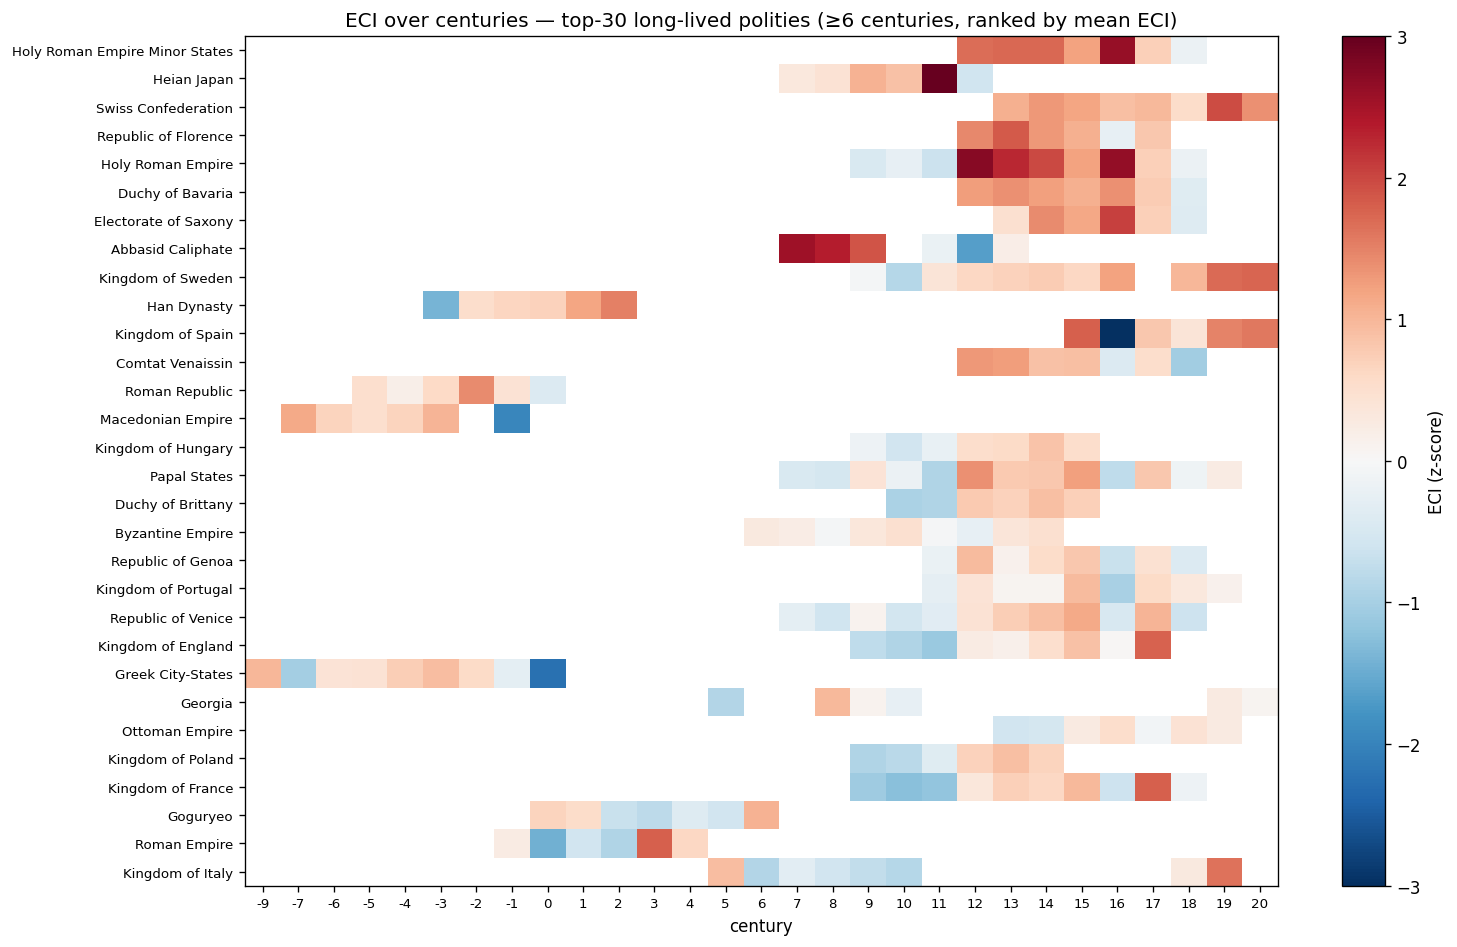

In [4]:
presence = df.groupby('polity_name')['century'].nunique().sort_values(ascending=False)
long_lived = presence[presence >= 6].index
# limit to the 30 with the highest mean ECI for readability
mean_eci = df[df.polity_name.isin(long_lived)].groupby('polity_name')['eci'].mean()
selected = mean_eci.sort_values(ascending=False).head(30).index.tolist()

pivot = (df[df.polity_name.isin(selected)]
         .pivot_table(index='polity_name', columns='century', values='eci'))
pivot = pivot.loc[selected]  # keep ECI-mean order

fig, ax = plt.subplots(figsize=(13, 8), dpi=120)
im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r',
               vmin=-3, vmax=3)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xlabel('century')
ax.set_title('ECI over centuries — top-30 long-lived polities (≥6 centuries, ranked by mean ECI)')
plt.colorbar(im, ax=ax, label='ECI (z-score)')
plt.tight_layout(); plt.show()


## 4. ECI trajectories of selected polities


not present in table: ['France']


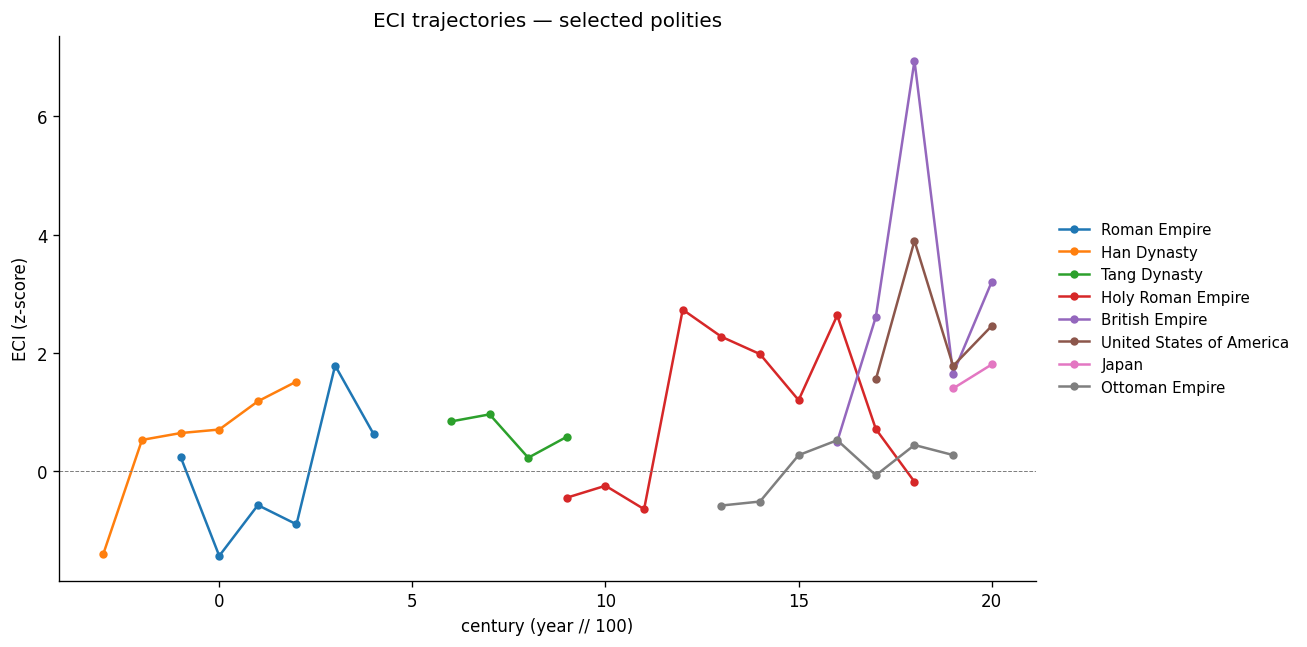

In [5]:
trajectories = [
    'Roman Empire', 'Han Dynasty', 'Tang Dynasty', 'Holy Roman Empire',
    'British Empire', 'France', 'United States of America', 'Japan',
    'Ottoman Empire',
]
available = [p for p in trajectories if p in df.polity_name.values]
missing = sorted(set(trajectories) - set(available))
if missing:
    print('not present in table:', missing)

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=120)
palette = plt.get_cmap('tab10').colors
for color, polity in zip(palette, available):
    sub = df[df.polity_name == polity].sort_values('century')
    ax.plot(sub.century, sub.eci, marker='o', label=polity, color=color, lw=1.5, ms=4)
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.set_xlabel('century (year // 100)')
ax.set_ylabel('ECI (z-score)')
ax.set_title('ECI trajectories — selected polities')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
plt.tight_layout(); plt.show()


## 5. ECI vs diversity

Is high-ECI just "big polity has many specialisations"?  Plot ECI against
diversity (number of occupations the polity is RCA-specialised in) for the
19th century (= years 1900-1999).


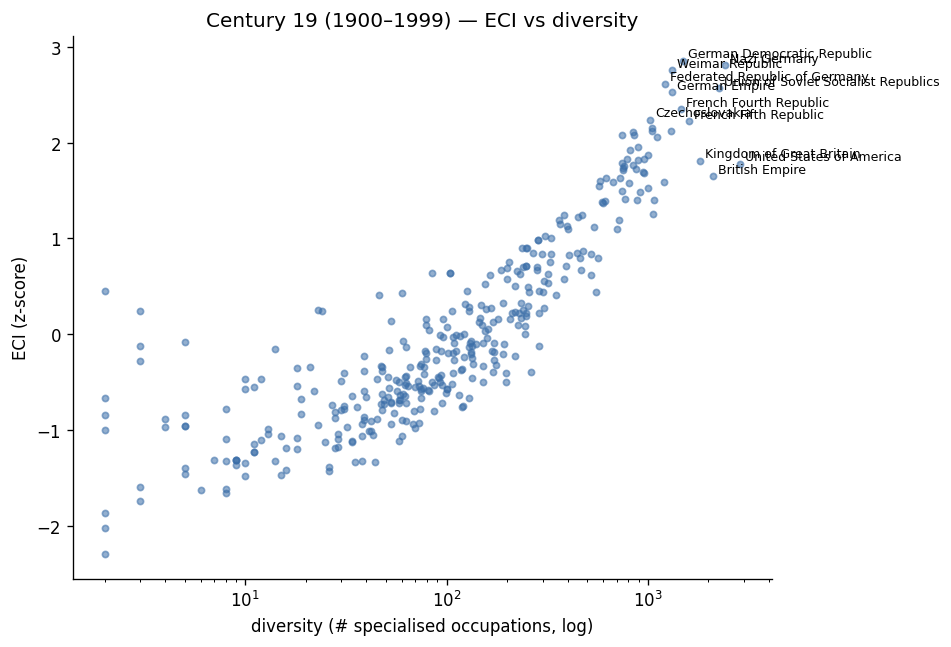

In [6]:
c = 19
sub = df[df.century == c].copy()
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=120)
ax.scatter(sub.diversity, sub.eci, s=14, alpha=0.55, color='#3b6ea8')
# label the top by diversity and the top by ECI
top_div = sub.nlargest(8, 'diversity')
top_eci = sub.nlargest(8, 'eci')
for _, row in pd.concat([top_div, top_eci]).drop_duplicates('polity_id').iterrows():
    ax.annotate(row.polity_name, (row.diversity, row.eci), fontsize=7.5,
                xytext=(3, 2), textcoords='offset points')
ax.set_xscale('log')
ax.set_xlabel('diversity (# specialised occupations, log)')
ax.set_ylabel('ECI (z-score)')
ax.set_title(f'Century {c} ({c*100}–{c*100+99}) — ECI vs diversity')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## 6. Distribution of ECI per century (boxplot)


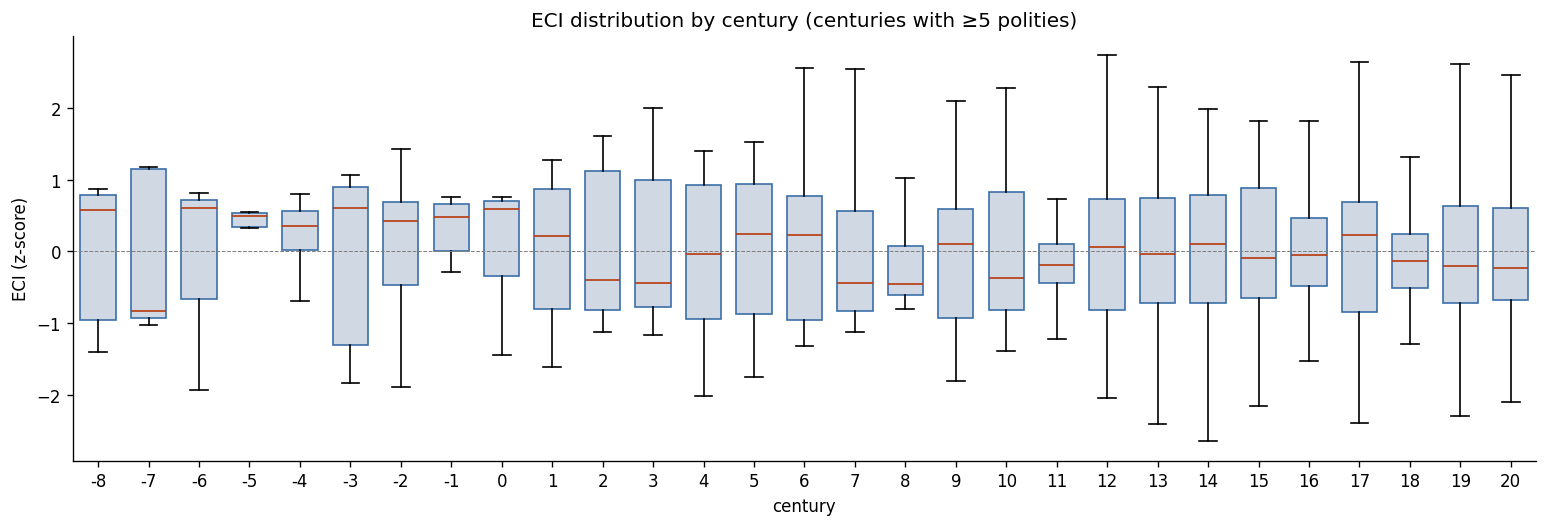

In [7]:
min_n = 5
show = df.groupby('century').filter(lambda g: len(g) >= min_n)
centuries_sorted = sorted(show.century.unique())
data = [show.loc[show.century == c, 'eci'].values for c in centuries_sorted]
fig, ax = plt.subplots(figsize=(13, 4.5), dpi=120)
ax.boxplot(data, positions=centuries_sorted, widths=0.7, showfliers=False,
           patch_artist=True, boxprops=dict(facecolor='#cfd8e3', edgecolor='#3b6ea8'),
           medianprops=dict(color='#b8390e'))
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.set_xlabel('century'); ax.set_ylabel('ECI (z-score)')
ax.set_title('ECI distribution by century (centuries with ≥5 polities)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## 7. Quick tabular browse

Top-10 polities by ECI in each century with at least 20 polities.


In [8]:
rich = df.groupby('century').filter(lambda g: len(g) >= 20)
for c, g in rich.groupby('century'):
    print(f'\n=== century {c}  ({c*100}–{c*100+99}) ===')
    cols = ['polity_name', 'n_individuals', 'total_hpi', 'diversity', 'eci']
    print(g.nlargest(10, 'eci')[cols].to_string(index=False))



=== century -5  (-500–-401) ===
             polity_name  n_individuals  total_hpi  diversity      eci
Spring and Autumn States              7       14.0        2.0 0.554332
                      Qi              4       11.0        2.0 0.554332
                     Chu              8      213.0        5.0 0.550396
    Warring States China             16      243.0        8.0 0.544579
                     Han              1        8.0        4.0 0.539645
                     Jin              1        8.0        4.0 0.539645
                      Wu              5       68.0        6.0 0.535752
                     Yue              5       68.0        6.0 0.535752
        Odrysian Kingdom              7       35.0        3.0 0.505600
   Sacred Band of Thebes              5      201.0        4.0 0.505542

=== century -4  (-400–-301) ===
           polity_name  n_individuals  total_hpi  diversity      eci
    Athenian Coalition            123     3367.0       36.0 0.799271
  Peloponnesian

## 8. Recompute ECI on the cross-verified ontology (level3)

The 18 k Wikidata occupation Q-ids are too granular and noisy
(many near-duplicates: `painter`, `oil painter`, `landscape painter`...).
We just stamped each occupation with the cross-verified ontology
(`Laouenan et al. 2022`, three nested levels stored on `occupations.levelN_main_occ`).

This section recomputes the polity × century ECI on **level3** (~1300 buckets,
e.g. `playwright`, `footballer`, `painter`, `physicist`).  The pipeline is
identical to sections 1-7 — only the *occupation key* changes:

1. join `individuals_keys.occupations_ids` → `occupations.level3_main_occ`,
2. aggregate HPI per `(individual, polity, century, level3_main_occ)`,
3. RCA → M_ik → second-eigenvector ECI, z-scored within each century.


In [ ]:
# 8.1 — load HPI per individual + polity-level3 long table from SQLite
import duckdb
import numpy as np
import polars as pl
from scipy.sparse import csr_matrix
from tqdm.auto import tqdm

DB_PATH = '../data/humans_clean.duckdb'

with duckdb.connect(DB_PATH, read_only=True) as con:
    con.text_factory = lambda b: b.decode('utf-8', errors='replace')

    print('Loading HPI...')
    hpi = con.execute('''SELECT wikidata_id, COUNT(DISTINCT property_id) AS hpi
              FROM identifiers GROUP BY wikidata_id''').pl()

    print('Loading occupation -> level3 map...')
    occ_map = con.execute('''SELECT id AS occ_id, level3_main_occ
              FROM occupations WHERE level3_main_occ IS NOT NULL
                                 AND level3_main_occ <> '' ''').pl()
    l3_lookup = dict(occ_map.select(['occ_id', 'level3_main_occ']).iter_rows())

    print('Loading polity assignments + occupation IDs + floruit_year...')
    df_raw = con.execute('''SELECT ic.wikidata_id, ic.polity_id, ic.polity_name,
                  ic.floruit_year, ik.occupations_ids
             FROM individuals_cliopatria ic
             JOIN individuals_keys ik USING (wikidata_id)
            WHERE ic.floruit_year IS NOT NULL
              AND ik.occupations_ids IS NOT NULL
              AND ik.occupations_ids <> '' ''').pl()

print(f'rows: {df_raw.height:,}')
df_raw = (
    df_raw.join(hpi, on='wikidata_id', how='left')
    .with_columns(pl.col('hpi').fill_null(0).cast(pl.Int32))
)
df_raw.head()


In [ ]:
# 8.2 — explode polities, dedupe (individual, polity), explode occupation Q-ids,
#        map to level3, drop unmapped, bin to centuries.
df_p = (
    df_raw.with_columns(
        pl.col('polity_id').cast(pl.Utf8).str.split(';').alias('polity_id_list'),
        pl.col('polity_name').cast(pl.Utf8).str.split(';').alias('polity_name_list'),
    )
    .drop(['polity_id', 'polity_name'])
    .with_columns(
        pl.struct(['polity_id_list', 'polity_name_list'])
          .map_elements(lambda s: list(zip(s['polity_id_list'], s['polity_name_list'])),
                        return_dtype=pl.List(pl.List(pl.Utf8)))
          .alias('_pairs')
    )
    .drop(['polity_id_list', 'polity_name_list'])
    .explode('_pairs')
    .with_columns(
        pl.col('_pairs').list.get(0).str.strip_chars().alias('polity_id'),
        pl.col('_pairs').list.get(1).str.strip_chars().alias('polity_name'),
    )
    .drop('_pairs')
    .filter(pl.col('polity_id') != '')
    .unique(subset=['wikidata_id', 'polity_id'])
)
print(f'(individual, polity) pairs: {df_p.height:,}')

df_o = (
    df_p.with_columns(pl.col('occupations_ids').str.split(';').alias('occ_id'))
    .explode('occ_id')
    .with_columns(pl.col('occ_id').str.strip_chars())
    .with_columns(pl.col('occ_id').replace_strict(l3_lookup, default=None).alias('level3'))
    .drop_nulls('level3')
    .filter(pl.col('level3') != '')
    .with_columns((pl.col('floruit_year').cast(pl.Int64) // 100).alias('century'))
    .select(['wikidata_id', 'polity_id', 'polity_name', 'century', 'level3', 'hpi'])
)
print(f'(individual, polity, level3) rows: {df_o.height:,}')
print(f'distinct level3 buckets: {df_o["level3"].n_unique():,}')
df_o.head()


In [ ]:
# 8.3 — same eigenvector pipeline as before, but on the level3 occupation grid.
def compute_eci(cell_df):
    """Take a polars DataFrame with columns polity_id, occupation, weight."""
    polities = cell_df['polity_id'].unique().to_list()
    occs = cell_df['occupation'].unique().to_list()
    if len(polities) < 3 or len(occs) < 3:
        return pl.DataFrame()
    pidx = {p: i for i, p in enumerate(polities)}
    oidx = {o: j for j, o in enumerate(occs)}
    rows = np.array([pidx[p] for p in cell_df['polity_id'].to_list()])
    cols = np.array([oidx[o] for o in cell_df['occupation'].to_list()])
    vals = cell_df['weight'].to_numpy().astype(float)
    N = csr_matrix((vals, (rows, cols)), shape=(len(polities), len(occs))).toarray()
    Ni = N.sum(1, keepdims=True); Nk = N.sum(0, keepdims=True); T = N.sum()
    if T == 0:
        return pl.DataFrame()
    with np.errstate(divide='ignore', invalid='ignore'):
        rca = (N / Ni) / (Nk / T)
        rca = np.nan_to_num(rca)
    M = (rca >= 1).astype(float)
    diversity_full = M.sum(1)
    keep_p = np.ones(M.shape[0], bool); keep_o = np.ones(M.shape[1], bool)
    for _ in range(50):
        Mp = M[np.ix_(keep_p, keep_o)]
        bad_p = Mp.sum(1) <= 1; bad_o = Mp.sum(0) <= 1
        if not bad_p.any() and not bad_o.any():
            break
        keep_p[np.where(keep_p)[0][bad_p]] = False
        keep_o[np.where(keep_o)[0][bad_o]] = False
    if keep_p.sum() < 3 or keep_o.sum() < 3:
        return pl.DataFrame({'polity_id': polities, 'eci': [None] * len(polities),
                             'diversity': diversity_full.tolist(), 'total_hpi': N.sum(1).tolist()})
    Mp = M[np.ix_(keep_p, keep_o)]
    div_p = Mp.sum(1); ubi_o = Mp.sum(0)
    A = (Mp / div_p[:, None]) @ (Mp / ubi_o[None, :]).T
    w, v = np.linalg.eig(A)
    order = np.argsort(-w.real)
    e = v[:, order[1]].real
    if np.corrcoef(e, div_p)[0, 1] < 0:
        e = -e
    e = (e - e.mean()) / (e.std() + 1e-12)
    eci_full = np.full(len(polities), np.nan)
    eci_full[np.where(keep_p)[0]] = e
    return pl.DataFrame({'polity_id': polities, 'eci': eci_full.tolist(),
                         'diversity': diversity_full.tolist(), 'total_hpi': N.sum(1).tolist()})

grouped = (
    df_o.group_by(['century', 'polity_id', 'level3']).agg(pl.col('hpi').sum().alias('weight'))
    .rename({'level3': 'occupation'})
)
n_indiv = (
    df_o.group_by(['century', 'polity_id'])
    .agg(pl.col('wikidata_id').n_unique().alias('n_individuals'))
)
name_map = dict(
    df_o.select(['polity_id', 'polity_name']).unique(subset=['polity_id']).iter_rows()
)

results = []
for c in tqdm(sorted(grouped['century'].unique().to_list()), desc='centuries'):
    sub = grouped.filter(pl.col('century') == c).select(['polity_id', 'occupation', 'weight'])
    out = compute_eci(sub)
    if out.is_empty():
        continue
    out = out.with_columns(pl.lit(c).alias('century'))
    results.append(out)

df_l3 = pl.concat(results, how='diagonal_relaxed')
df_l3 = (
    df_l3.join(n_indiv, on=['century', 'polity_id'], how='left')
    .with_columns(pl.col('polity_id').replace_strict(name_map, default=None).alias('polity_name'))
    .select(['century', 'polity_id', 'polity_name', 'n_individuals', 'total_hpi', 'diversity', 'eci'])
)
# Convert to pandas for downstream pivot_table/heatmap cells
df_l3 = df_l3.to_pandas()
print(f'rows: {len(df_l3):,} | valid ECI: {df_l3.eci.notna().sum():,}')
df_l3.head()


### 8.4 Top-15 polities per century — level3 ontology

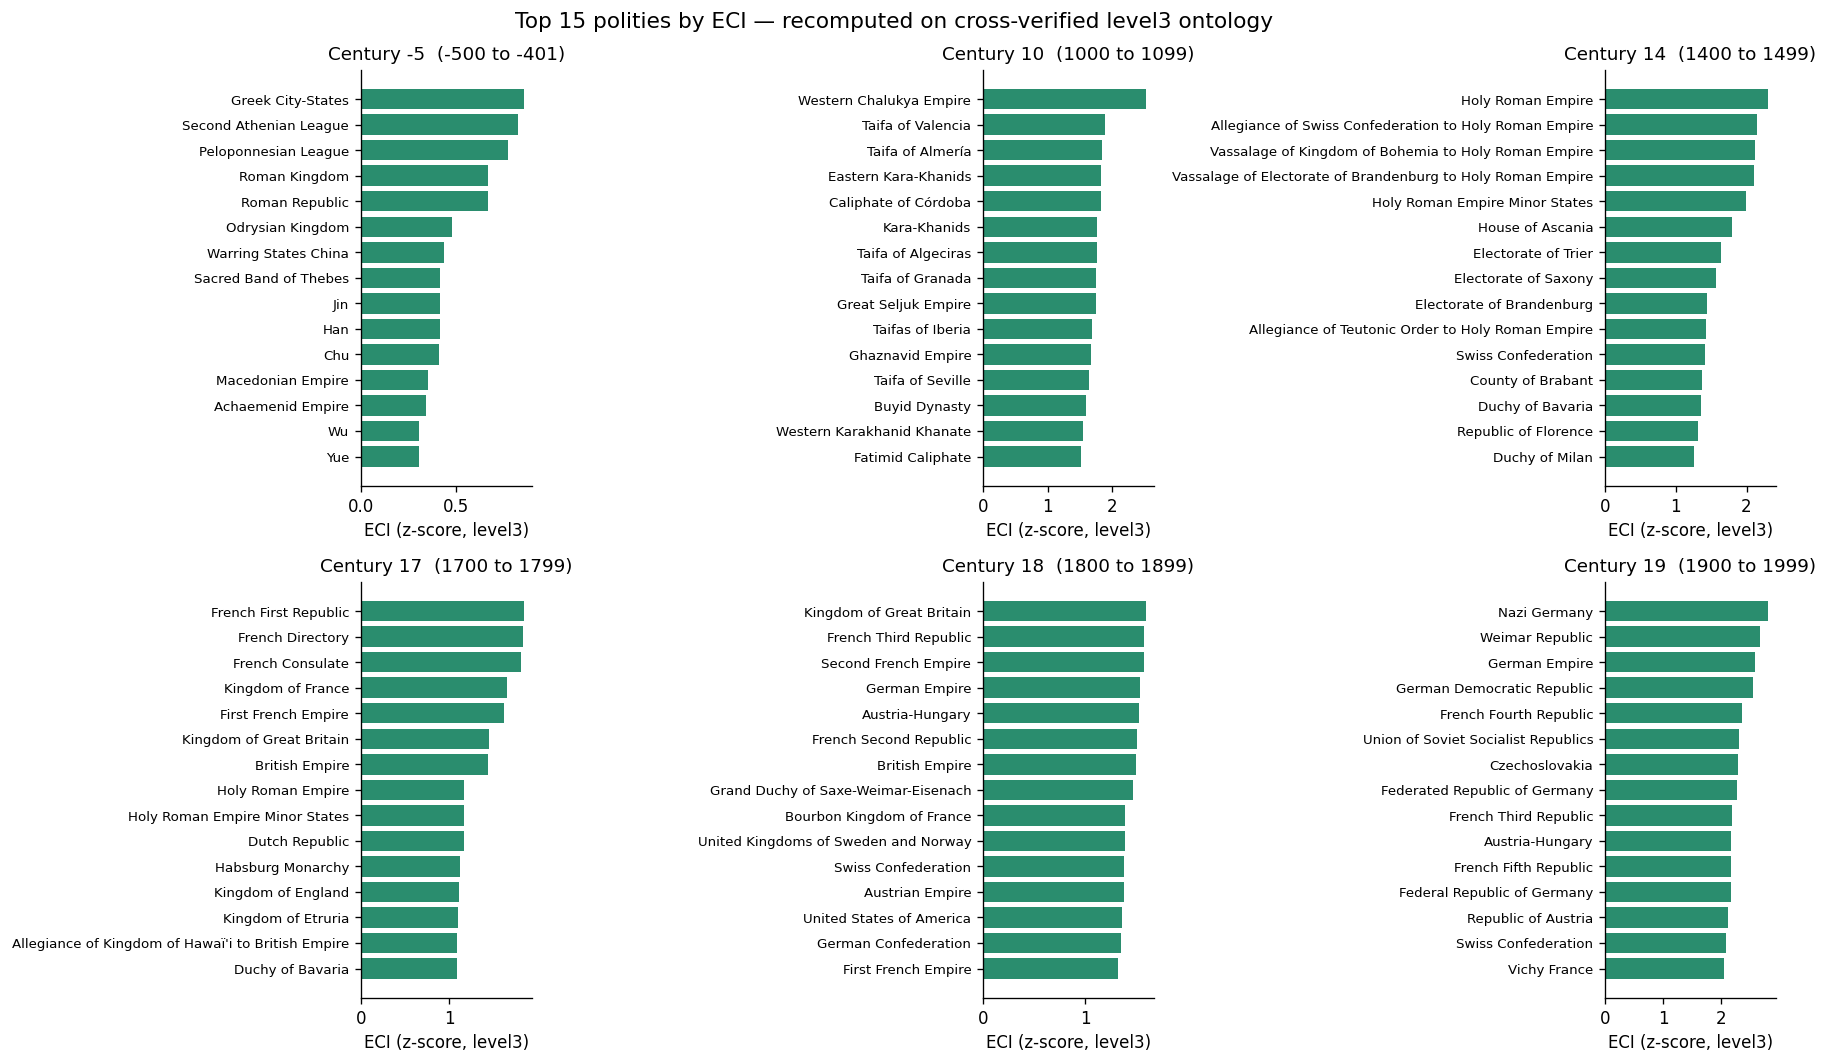

In [12]:
highlight_centuries = [-5, 10, 14, 17, 18, 19]
fig, axes = plt.subplots(2, 3, figsize=(15, 9), dpi=120)
for ax, c in zip(axes.flat, highlight_centuries):
    sub = df_l3[df_l3.century == c].dropna(subset=['eci']).nlargest(15, 'eci')
    ax.barh(sub.polity_name[::-1], sub.eci[::-1], color='#2a8d6e')
    ax.set_title(f'Century {c}  ({c*100} to {c*100+99})', fontsize=11)
    ax.set_xlabel('ECI (z-score, level3)')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
fig.suptitle('Top 15 polities by ECI — recomputed on cross-verified level3 ontology', fontsize=13)
plt.tight_layout(); plt.show()


### 8.5 Wikidata-occupation ECI vs level3-ontology ECI

How much does the ECI ranking change when we move from raw Wikidata
occupations (~18 k) to the cross-verified level3 ontology (~1.3 k)?


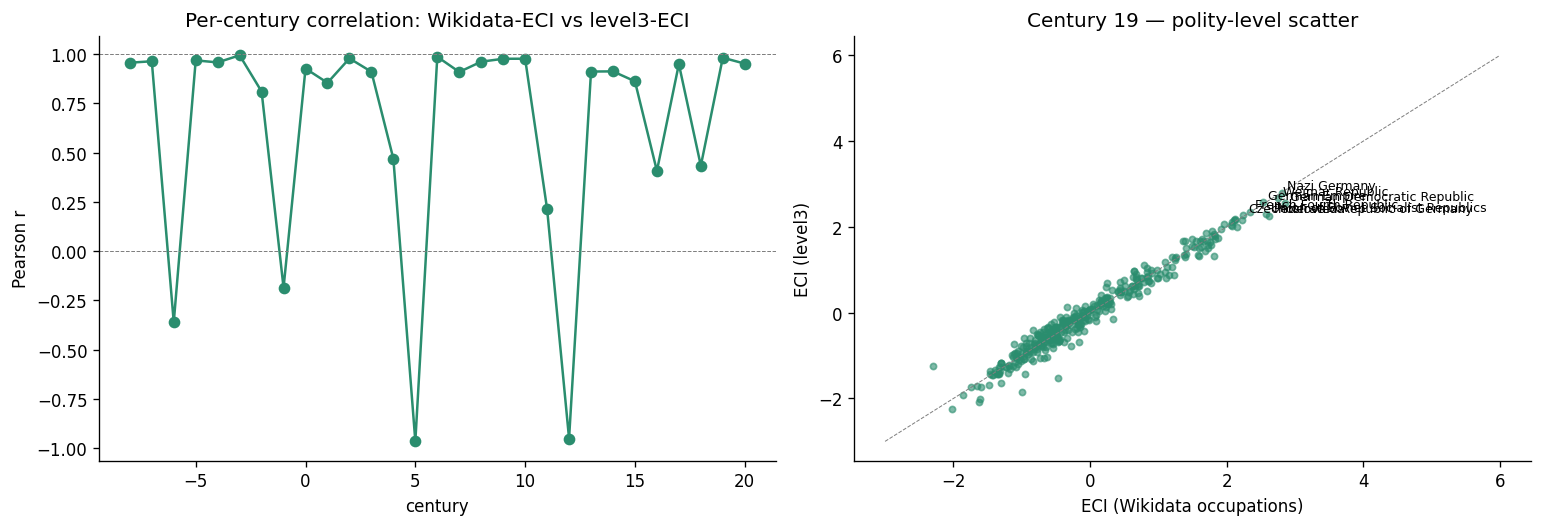

mean per-century correlation: 0.647


In [13]:
merged = df.merge(  # df = the parquet ECI table from cell 1
    
    df_l3.rename(columns={'eci':'eci_l3','diversity':'div_l3','total_hpi':'hpi_l3'}),
    on=['century','polity_id'], how='inner', suffixes=('','_drop'))
merged = merged.dropna(subset=['eci','eci_l3'])

corr = merged.groupby('century').apply(
    lambda g: g[['eci','eci_l3']].corr().iloc[0,1] if len(g) > 5 else np.nan
).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=120)
axes[0].plot(corr.index, corr.values, marker='o', color='#2a8d6e')
axes[0].axhline(1, ls='--', lw=0.6, color='gray'); axes[0].axhline(0, ls='--', lw=0.6, color='gray')
axes[0].set_xlabel('century'); axes[0].set_ylabel('Pearson r')
axes[0].set_title('Per-century correlation: Wikidata-ECI vs level3-ECI')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

c = 19
sub = merged[merged.century == c]
axes[1].scatter(sub.eci, sub.eci_l3, s=14, alpha=0.6, color='#2a8d6e')
lo, hi = -3, 6
axes[1].plot([lo,hi],[lo,hi], ls='--', color='gray', lw=0.6)
for _, row in sub.nlargest(8, 'eci_l3').iterrows():
    axes[1].annotate(row.polity_name, (row.eci, row.eci_l3),
                     fontsize=7.5, xytext=(3,2), textcoords='offset points')
axes[1].set_xlabel('ECI (Wikidata occupations)'); axes[1].set_ylabel('ECI (level3)')
axes[1].set_title(f'Century {c} — polity-level scatter')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print('mean per-century correlation:', corr.mean().round(3))


### 8.6 ECI heatmap on the level3 ontology

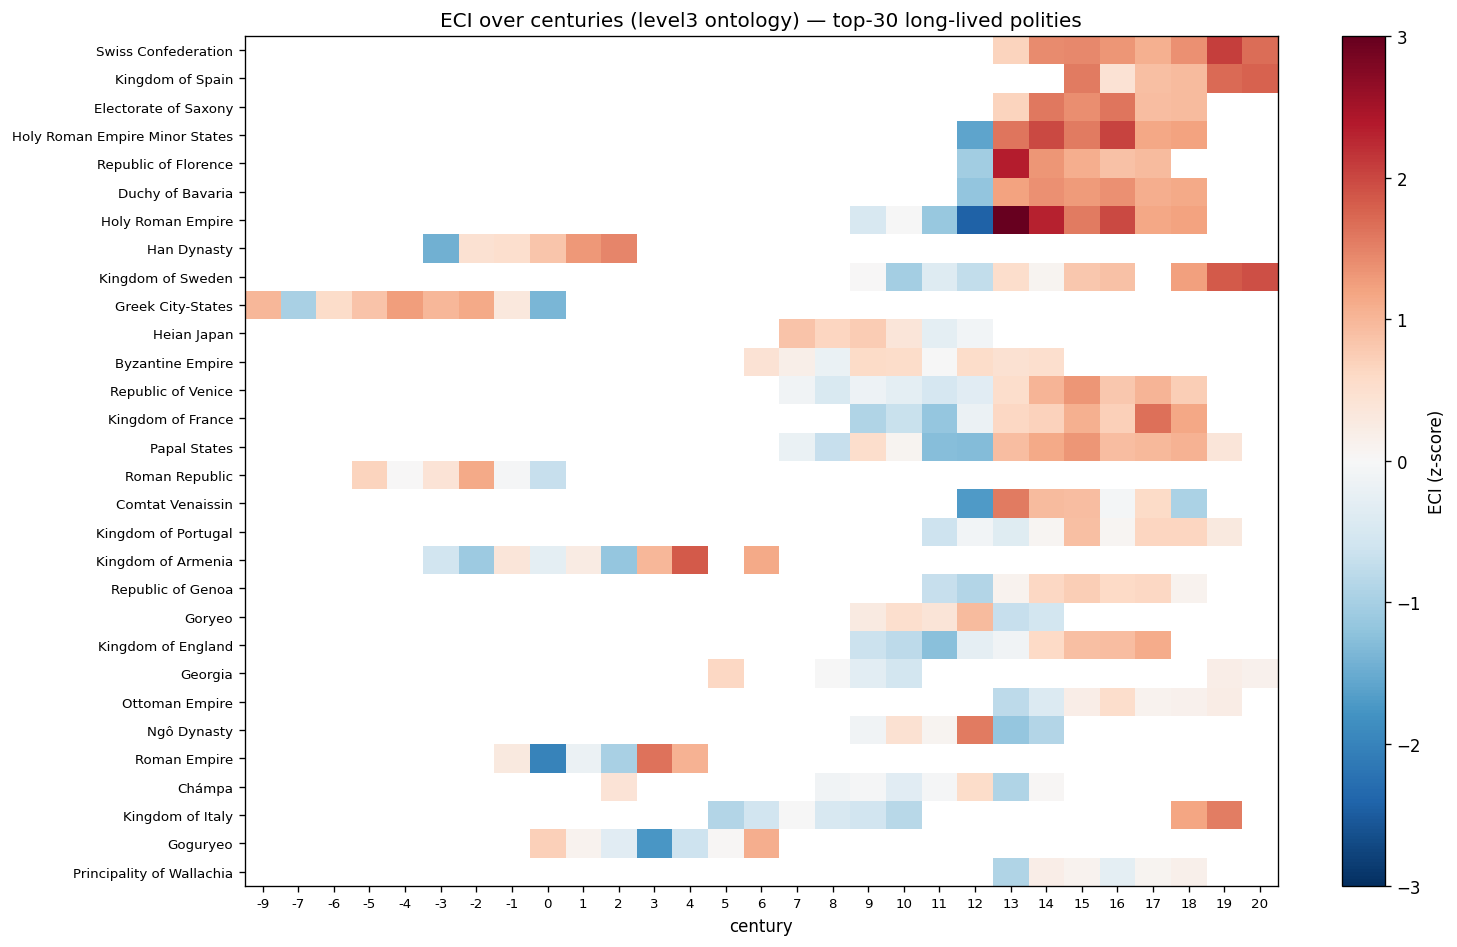

In [14]:
presence = df_l3.dropna(subset=['eci']).groupby('polity_name')['century'].nunique().sort_values(ascending=False)
long_lived = presence[presence >= 6].index
mean_eci = df_l3[df_l3.polity_name.isin(long_lived)].groupby('polity_name')['eci'].mean()
selected = mean_eci.sort_values(ascending=False).head(30).index.tolist()

pivot = (df_l3[df_l3.polity_name.isin(selected)]
            .pivot_table(index='polity_name', columns='century', values='eci'))
pivot = pivot.loc[selected]

fig, ax = plt.subplots(figsize=(13, 8), dpi=120)
im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, fontsize=8)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xlabel('century')
ax.set_title('ECI over centuries (level3 ontology) — top-30 long-lived polities')
plt.colorbar(im, ax=ax, label='ECI (z-score)')
plt.tight_layout(); plt.show()


### 8.7 Save level3 ECI table

In [15]:
out = '../data/eci_polity_century_level3.parquet'
df_l3.to_parquet(out, index=False)
print('wrote', out, '|', len(df_l3), 'rows')


wrote ../data/eci_polity_century_level3.parquet | 3263 rows


## 9. ECI trajectories on level2 and level3 ontologies

Same trajectories as section 4, but recomputed on the cross-verified
ontology — first on **level2** (~15 buckets: Culture-core, Politics,
Academia, Sports/Games, ...), then on **level3** (~1.3 k buckets:
playwright, footballer, painter, physicist, ...).


In [ ]:
# 9.1 — recompute ECI on level2 ontology
with duckdb.connect(DB_PATH, read_only=True) as con:
    con.text_factory = lambda b: b.decode('utf-8', errors='replace')
    occ_l2 = con.execute('''SELECT id AS occ_id, level2_main_occ
              FROM occupations
             WHERE level2_main_occ IS NOT NULL AND level2_main_occ <> '' ''').pl()
l2_lookup = dict(occ_l2.select(['occ_id', 'level2_main_occ']).iter_rows())

df_o2 = (
    df_p.with_columns(pl.col('occupations_ids').str.split(';').alias('occ_id'))
    .explode('occ_id')
    .with_columns(pl.col('occ_id').str.strip_chars())
    .with_columns(pl.col('occ_id').replace_strict(l2_lookup, default=None).alias('level2'))
    .drop_nulls('level2')
    .filter(pl.col('level2') != '')
    .with_columns((pl.col('floruit_year').cast(pl.Int64) // 100).alias('century'))
    .select(['wikidata_id', 'polity_id', 'polity_name', 'century', 'level2', 'hpi'])
)
print(f'(individual, polity, level2) rows: {df_o2.height:,}  | distinct level2: {df_o2["level2"].n_unique()}')

grouped2 = (
    df_o2.group_by(['century', 'polity_id', 'level2']).agg(pl.col('hpi').sum().alias('weight'))
    .rename({'level2': 'occupation'})
)
n_indiv2 = (
    df_o2.group_by(['century', 'polity_id'])
    .agg(pl.col('wikidata_id').n_unique().alias('n_individuals'))
)
name_map2 = dict(
    df_o2.select(['polity_id', 'polity_name']).unique(subset=['polity_id']).iter_rows()
)

results2 = []
for c in tqdm(sorted(grouped2['century'].unique().to_list()), desc='centuries (l2)'):
    sub = grouped2.filter(pl.col('century') == c).select(['polity_id', 'occupation', 'weight'])
    out = compute_eci(sub)
    if out.is_empty():
        continue
    out = out.with_columns(pl.lit(c).alias('century'))
    results2.append(out)

df_l2 = pl.concat(results2, how='diagonal_relaxed')
df_l2 = (
    df_l2.join(n_indiv2, on=['century', 'polity_id'], how='left')
    .with_columns(pl.col('polity_id').replace_strict(name_map2, default=None).alias('polity_name'))
    .select(['century', 'polity_id', 'polity_name', 'n_individuals', 'total_hpi', 'diversity', 'eci'])
)
df_l2 = df_l2.to_pandas()
print(f'level2 rows: {len(df_l2):,} | valid ECI: {df_l2.eci.notna().sum():,}')
df_l2.head()


### 9.2 Trajectories — level2 vs level3

level2: not present -> ['France']
level3: not present -> ['France']


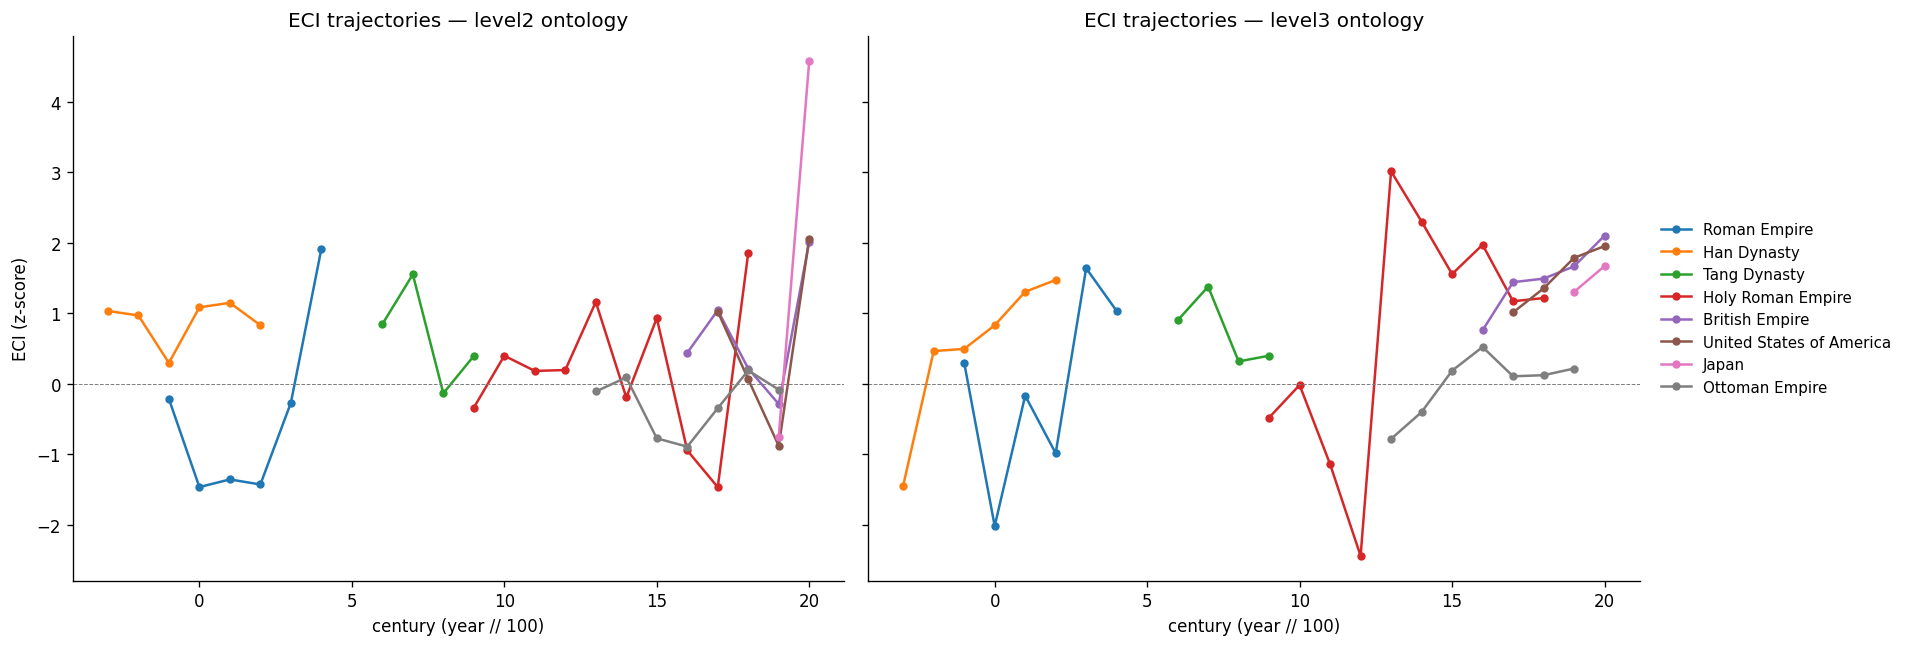

In [17]:
trajectories = [
    'Roman Empire', 'Han Dynasty', 'Tang Dynasty', 'Holy Roman Empire',
    'British Empire', 'France', 'United States of America', 'Japan',
    'Ottoman Empire',
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), dpi=120, sharey=True)
palette = plt.get_cmap('tab10').colors

for ax, (label, frame) in zip(axes, [('level2', df_l2), ('level3', df_l3)]):
    avail = [p for p in trajectories if p in frame.polity_name.values]
    miss = sorted(set(trajectories) - set(avail))
    if miss:
        print(f'{label}: not present ->', miss)
    for color, polity in zip(palette, avail):
        sub = frame[frame.polity_name == polity].dropna(subset=['eci']).sort_values('century')
        ax.plot(sub.century, sub.eci, marker='o', label=polity, color=color, lw=1.5, ms=4)
    ax.axhline(0, color='gray', lw=0.6, ls='--')
    ax.set_xlabel('century (year // 100)')
    ax.set_title(f'ECI trajectories — {label} ontology')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

axes[0].set_ylabel('ECI (z-score)')
axes[1].legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
plt.tight_layout(); plt.show()
